
## Project Overview

This project focuses on building a machine learning–based classification system to predict whether an insurance policyholder is likely to file an insurance claim. While the problem appears simple at first glance, it becomes challenging due to the limited number of samples and the slight class imbalance present in the dataset. These characteristics closely resemble real-world insurance data, where claim events are relatively rare compared to non-claim cases.

The goal of this project is to overcome these challenges and develop a robust predictive model capable of accurately classifying claim and non-claim instances.




## Dataset Description

The project uses the Sample Insurance Claim Prediction Dataset, which is based on the Medical Cost Personal Dataset and enhanced with updated sample values. Each record represents an individual policyholder with demographic, lifestyle, and insurance-related attributes.

## Features included in the dataset:

age: Age of the policyholder

sex: Gender of the policyholder (female = 0, male = 1)

bmi: Body Mass Index (kg/m²), an indicator of body weight relative to height

steps: Average walking steps per day

children: Number of dependents covered by the policy

smoker: Smoking status (non-smoker = 0, smoker = 1)

region: Residential area in the US

northeast = 0, northwest = 1, southeast = 2, southwest = 3

charges: Individual medical costs billed by health insurance

insuranceclaim: Target variable indicating claim status (yes = 1, no = 0)


## Problem Statement

The task is to predict whether a policyholder will file an insurance claim based on the available features. Since claim cases are fewer than non-claim cases, traditional accuracy-based modeling may lead to biased results, making it essential to use proper evaluation techniques.

## Stractegic Plan of Action:

We aim to solve the problem statement by creating a plan of action, Here are some of the necessary steps:

Data Exploration
Exploratory Data Analysis (EDA)
Data Pre-processing
Data Manipulation
Feature Selection/Extraction
Predictive Modelling
Project Outcomes & Conclusion

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math
from imblearn.over_sampling import SMOTE
import lazypredict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from tqdm import tqdm
from sklearn.feature_selection import RFE


# Display options.
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

In [35]:
path = "C:\\Users\\utkar\\Downloads\\insurance.csv"
df = pd.read_csv(path)

target = 'insuranceclaim'
labels = ['Claimed','Not Claimed']
features = [i for i in df.columns.values if i not in [target]]

original_df = df.copy(deep=True)
display(df.head())

print('\n\033[1mInference:\033[0m The Datset consists of {} features & {} samples.'.format(df.shape[1], df.shape[0]))

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1



Inference: The Datset consists of 8 features & 1338 samples.


In [36]:
df.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


In [37]:
df.tail()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
1333,50,1,30.97,3,0,1,10600.5483,0
1334,18,0,31.92,0,0,0,2205.9808,1
1335,18,0,36.85,0,0,2,1629.8335,1
1336,21,0,25.80,0,0,3,2007.9450,0
1337,61,0,29.07,0,1,1,29141.3603,1


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   age             int64  
 1   sex             int64  
 2   bmi             float64
 3   children        int64  
 4   smoker          int64  
 5   region          int64  
 6   charges         float64
 7   insuranceclaim  int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
sex,1338.0,0.505232,0.500160,0.0000,0.00000,1.000,1.000000,1.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
smoker,1338.0,0.204783,0.403694,0.0000,0.00000,0.000,0.000000,1.00000
region,1338.0,1.515695,1.104885,0.0000,1.00000,2.000,2.000000,3.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801
insuranceclaim,1338.0,0.585202,0.492871,0.0000,0.00000,1.000,1.000000,1.00000


In [40]:
#Checking number of unique rows in each feature

df.nunique().sort_values()

sex                  2
smoker               2
insuranceclaim       2
region               4
children             6
age                 47
bmi                548
charges           1337
dtype: int64

In [41]:
#Checking number of unique rows in each feature

nu = df[features].nunique().sort_values()
nf = []; cf = []; nnf = 0; ncf = 0; #numerical & categorical features

for i in range(df[features].shape[1]):
    if nu.values[i]<=7:cf.append(nu.index[i])
    else: nf.append(nu.index[i])

print('\n\033[1mInference:\033[0m The Datset has {} numerical & {} categorical features.'.format(len(nf),len(cf)))


Inference: The Datset has 3 numerical & 4 categorical features.


In [42]:
#Checking the stats of all the columns

display(df.describe())

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265,0.585202
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237,0.492871
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900,0.000000
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000,1.000000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515,1.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010,1.000000


Inference: The stats seem to be fine, let us gain more undestanding by visualising the dataset.

## 2. Exploratory Data Analysis (EDA)

            Target Variable Distribution           


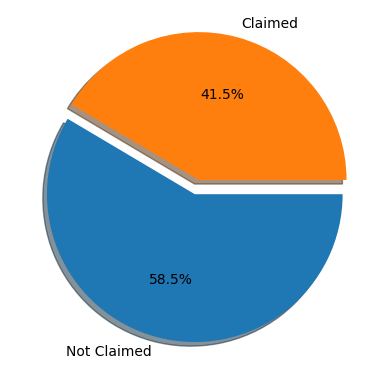

In [43]:
#Let us first analyze the distribution of the target variable

MAP={}
for e, i in enumerate(sorted(df[target].unique())):
    MAP[i]=labels[e]
#MAP={0:'Not-Survived',1:'Survived'}
df1 = df.copy()
df1[target]=df1[target].map(MAP)
explode=np.zeros(len(labels))
explode[-1]=0.1
print('\033[1mTarget Variable Distribution'.center(55))
plt.pie(df1[target].value_counts(), labels=df1[target].value_counts().index, counterclock=False, shadow=True, 
        explode=explode, autopct='%1.1f%%', radius=1, startangle=0)
plt.show()

Inference: The Target Variable seems to be slightly imbalanced! Hence we shall try to perform data augmentation.

                               Categorical Features Distribution:                               


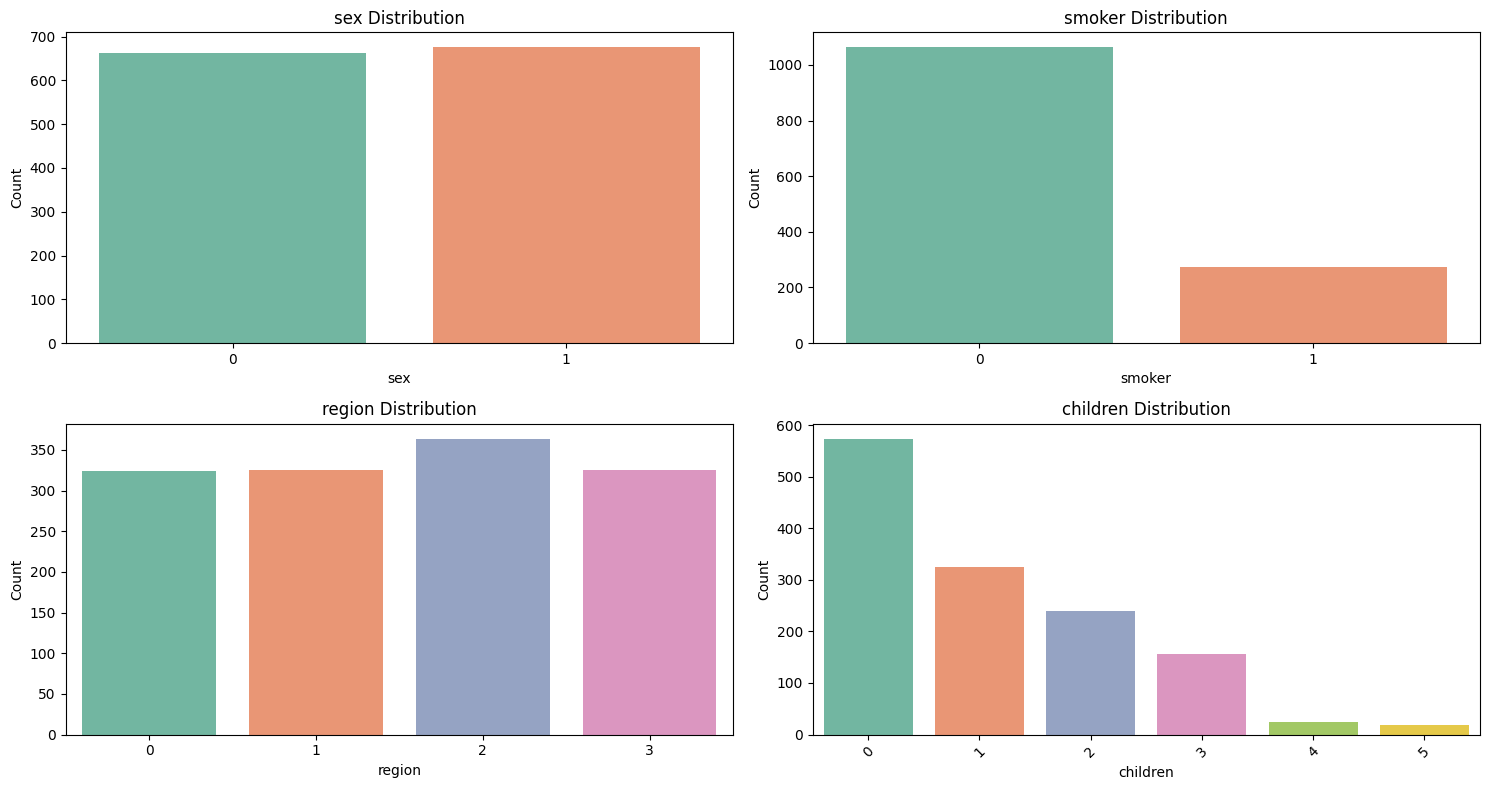

In [44]:
# Visualizing all categorical features with count plots
print('\033[1mCategorical Features Distribution:'.center(100))

n_cols = 2  # Number of columns in subplot grid
n_rows = math.ceil(len(cf) / n_cols)

plt.figure(figsize=[15, 4*n_rows])

for i in range(len(cf)):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data=df, x=cf[i], palette='Set2')
    plt.title(f'{cf[i]} Distribution')
    plt.xlabel(cf[i])
    plt.ylabel('Count')
    
    # Rotate x-axis labels if there are many unique values
    if df[cf[i]].nunique() > 5:
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Inference: Visualizing the categorical features reveal lot of information about the dataset.

                                     Features Distribution                                      


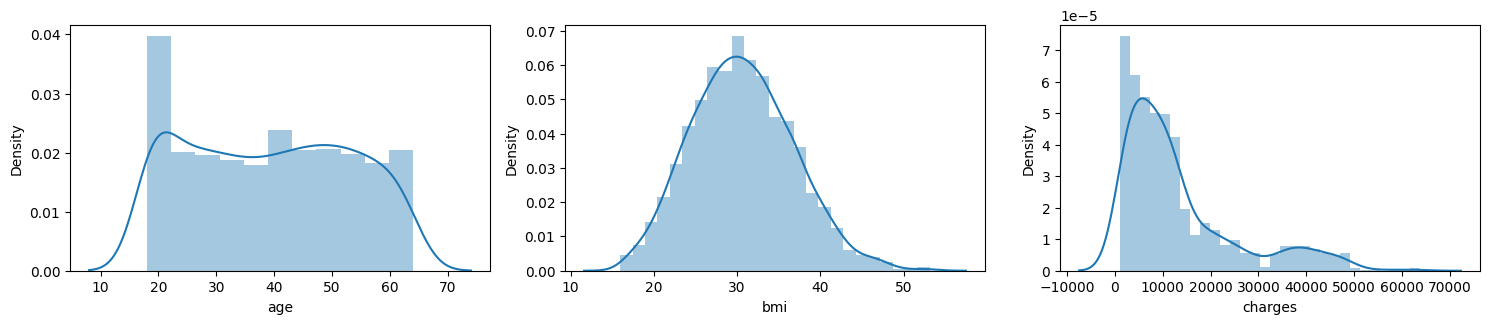

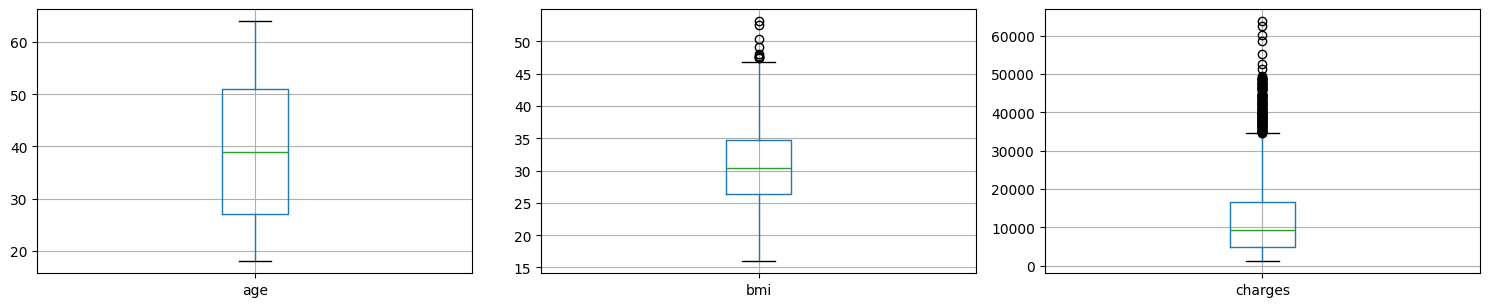

In [45]:
#Understanding the feature set

print('\033[1mFeatures Distribution'.center(100))

nf = [i for i in features if i not in cf]

plt.figure(figsize=[15,3*math.ceil(len(features)/3)])
for c in range(len(nf)):
    plt.subplot(math.ceil(len(features)/3),3,c+1)
    sns.distplot(df[nf[c]])
plt.tight_layout()
plt.show()

plt.figure(figsize=[15,3*math.ceil(len(features)/3)])
for c in range(len(nf)):
    plt.subplot(math.ceil(len(features)/3),3,c+1)
    df.boxplot(nf[c])
plt.tight_layout()
plt.show()

Inference: The data is somewhat normally distributed. And there are many outliers present in the dataset. We shall fix these outliers..

## 3. Data Preprocessing

In [46]:
#Removal of any Duplicate rows (if any)

counter = 0
r,c = original_df.shape

df1 = df.copy()
df1.drop_duplicates(inplace=True)
df1.reset_index(drop=True,inplace=True)

if df1.shape==(r,c):
    print('\n\033[1mInference:\033[0m The dataset doesn\'t have any duplicates')
else:
    print(f'\n\033[1mInference:\033[0m Number of duplicates dropped ---> {r-df1.shape[0]}')


Inference: Number of duplicates dropped ---> 1


In [47]:
#Check for empty elements

nvc = pd.DataFrame(df1.isnull().sum().sort_values(), columns=['Total Null Values'])
nvc['Percentage'] = round(nvc['Total Null Values']/df1.shape[0],3)*100
print(nvc)

                Total Null Values  Percentage
age                             0         0.0
sex                             0         0.0
bmi                             0         0.0
children                        0         0.0
smoker                          0         0.0
region                          0         0.0
charges                         0         0.0
insuranceclaim                  0         0.0


Inference: There are many outliers in the dataset. Let us try to impute the missing values

In [48]:
#Converting categorical Columns to Numeric

#df1 = df.copy()
ecc = nvc[nvc['Percentage']!=0].index.values
dcc = [i for i in df.columns if i not in ecc]

df3 = df1[dcc]
fcc = [i for i in cf if i not in ecc]

#One-Hot Binay Encoding
oh=True
dm=True
for i in fcc:
    #print(i)
    if df3[i].nunique()==2:
        if oh==True: print("\033[1m\nOne-Hot Encoding on features:\033[0m")
        print(i);oh=False
        df3[i]=pd.get_dummies(df3[i], drop_first=True, prefix=str(i))
    if (df3[i].nunique()>2 and df3[i].nunique()<17):
        if dm==True: print("\n\033[1mDummy Encoding on features:\033[0m")
        print(i);dm=False
        df3 = pd.concat([df3.drop([i], axis=1), pd.DataFrame(pd.get_dummies(df3[i], drop_first=True, prefix=str(i)))],axis=1)
        
df3.shape


One-Hot Encoding on features:
sex
smoker

Dummy Encoding on features:
region
children


(1337, 14)

In [49]:
#Removal of outlier:

df4 = df3.copy()

for i in [i for i in df4.columns]:
    if df4[i].nunique()>=12:
        Q1 = df4[i].quantile(0.25)
        Q3 = df4[i].quantile(0.75)
        IQR = Q3 - Q1
        df4 = df4[df4[i] <= (Q3+(1.5*IQR))]
        df4 = df4[df4[i] >= (Q1-(1.5*IQR))]
df4 = df4.reset_index(drop=True)
display(df4.head())
print('\n\033[1mInference:\033[0m Before removal of outliers, The dataset had {} samples.'.format(df1.shape[0]))
print('\033[1mInference:\033[0m After removal of outliers, The dataset now has {} samples.'.format(df4.shape[0]))

,age,sex,bmi,smoker,charges,insuranceclaim,region_1,region_2,region_3,children_1,children_2,children_3,children_4,children_5
0,19,False,27.900,True,16884.92400,1,False,False,True,False,False,False,False,False
1,18,True,33.770,False,1725.55230,1,False,True,False,True,False,False,False,False
2,28,True,33.000,False,4449.46200,0,False,True,False,False,False,True,False,False
3,33,True,22.705,False,21984.47061,0,True,False,False,False,False,False,False,False
4,32,True,28.880,False,3866.85520,1,True,False,False,False,False,False,False,False



Inference: Before removal of outliers, The dataset had 1337 samples.
Inference: After removal of outliers, The dataset now has 1190 samples.


In [50]:
#Fixing the imbalance using SMOTE Technique

df5 = df4.copy()

print('Original class distribution:')
print(df5[target].value_counts())

xf = df5.columns
X = df5.drop([target],axis=1)
Y = df5[target]

smote = SMOTE()
X, Y = smote.fit_resample(X, Y)

df5 = pd.DataFrame(X, columns=xf)
df5[target] = Y

print('\nClass distribution after applying SMOTE Technique:',)
print(Y.value_counts())

Original class distribution:
insuranceclaim
1    638
0    552
Name: count, dtype: int64

Class distribution after applying SMOTE Technique:
insuranceclaim
1    638
0    638
Name: count, dtype: int64


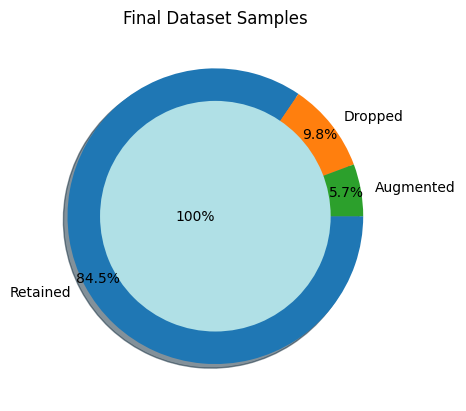


Inference:The final dataset after cleanup has 1276 samples & 14 columns.


In [51]:
#Final Dataset size after performing Preprocessing

df = df5.copy()
plt.title('Final Dataset Samples')
plt.pie([df.shape[0], original_df.shape[0]-df4.shape[0], df5.shape[0]-df4.shape[0]], radius = 1, shadow=True,
        labels=['Retained','Dropped','Augmented'], counterclock=False, autopct='%1.1f%%', pctdistance=0.9, explode=[0,0,0])
plt.pie([df.shape[0]], labels=['100%'], labeldistance=-0, radius=0.78, shadow=True, colors=['powderblue'])
plt.show()

print('\n\033[1mInference:\033[0mThe final dataset after cleanup has {} samples & {} columns.'.format(df.shape[0], df.shape[1]))    

## 4. Data Manipulation

In [52]:
#Splitting the data intro training & testing sets

df = df5.copy()

X = df.drop([target],axis=1)
Y = df[target]
Train_X, Test_X, Train_Y, Test_Y = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=0)

print('Original set  ---> ',X.shape,Y.shape,'\nTraining set  ---> ',Train_X.shape,Train_Y.shape,'\nTesting set   ---> ', Test_X.shape,'', Test_Y.shape)

Original set  --->  (1276, 13) (1276,) 
Training set  --->  (1020, 13) (1020,) 
Testing set   --->  (256, 13)  (256,)


In [53]:
#Feature Scaling (Standardization)

std = StandardScaler()

print('\033[1mStandardardization on Training set'.center(100))
Train_X_std = std.fit_transform(Train_X)
Train_X_std = pd.DataFrame(Train_X_std, columns=X.columns)
display(Train_X_std.describe())

print('\n','\033[1mStandardardization on Testing set'.center(100))
Test_X_std = std.transform(Test_X)
Test_X_std = pd.DataFrame(Test_X_std, columns=X.columns)
display(Test_X_std.describe())

                               Standardardization on Training set                               


,age,sex,bmi,smoker,charges,region_1,region_2,region_3,children_1,children_2,children_3,children_4,children_5
count,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03
mean,-2.290107e-16,2.438137e-17,4.484430e-16,-3.831358e-17,-2.089832e-16,-6.791953e-17,-1.262607e-17,4.179663e-17,-2.612289e-17,5.224579e-18,8.011021e-17,1.741526e-17,-6.966105e-18
std,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00
min,-1.475757e+00,-1.013821e+00,-2.378035e+00,-3.634219e-01,-1.213706e+00,-6.181536e-01,-5.818786e-01,-5.788597e-01,-5.833881e-01,-4.907911e-01,-3.838705e-01,-1.617311e-01,-1.449863e-01
25%,-9.025928e-01,-1.013821e+00,-7.388543e-01,-3.634219e-01,-7.597178e-01,-6.181536e-01,-5.818786e-01,-5.788597e-01,-5.833881e-01,-4.907911e-01,-3.838705e-01,-1.617311e-01,-1.449863e-01
50%,-4.284682e-02,9.863674e-01,-3.955490e-02,-3.634219e-01,-2.288678e-01,-6.181536e-01,-5.818786e-01,-5.788597e-01,-5.833881e-01,-4.907911e-01,-3.838705e-01,-1.617311e-01,-1.449863e-01
75%,8.885447e-01,9.863674e-01,6.380575e-01,-3.634219e-01,4.203321e-01,1.617721e+00,1.718572e+00,1.727534e+00,1.714125e+00,-4.907911e-01,-3.838705e-01,-1.617311e-01,-1.449863e-01
max,1.819936e+00,9.863674e-01,2.934636e+00,2.751623e+00,3.379322e+00,1.617721e+00,1.718572e+00,1.727534e+00,1.714125e+00,2.037527e+00,2.605045e+00,6.183104e+00,6.897204e+00



                                Standardardization on Testing set                                


,age,sex,bmi,smoker,charges,region_1,region_2,region_3,children_1,children_2,children_3,children_4,children_5
count,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000
mean,0.060423,-0.044980,0.090489,0.001622,-0.027551,-0.085387,0.083095,0.060804,0.026889,-0.036484,0.083148,-0.112162,-0.034952
std,1.014085,1.001564,1.011444,1.003897,0.926086,0.954420,1.044899,1.034567,1.016720,0.972591,1.087378,0.559709,0.875080
min,-1.475757,-1.013821,-1.853497,-0.363422,-1.210997,-0.618154,-0.581879,-0.578860,-0.583388,-0.490791,-0.383871,-0.161731,-0.144986
25%,-0.830947,-1.013821,-0.656895,-0.363422,-0.771059,-0.618154,-0.581879,-0.578860,-0.583388,-0.490791,-0.383871,-0.161731,-0.144986
50%,0.064621,-1.013821,0.011274,-0.363422,-0.180223,-0.618154,-0.581879,-0.578860,-0.583388,-0.490791,-0.383871,-0.161731,-0.144986
75%,0.960190,0.986367,0.756251,-0.363422,0.425324,-0.618154,1.718572,1.727534,1.714125,-0.490791,-0.383871,-0.161731,-0.144986
max,1.819936,0.986367,2.896676,2.751623,3.264266,1.617721,1.718572,1.727534,1.714125,2.037527,2.605045,6.183104,6.897204


## 5. Feature Selection/Extraction

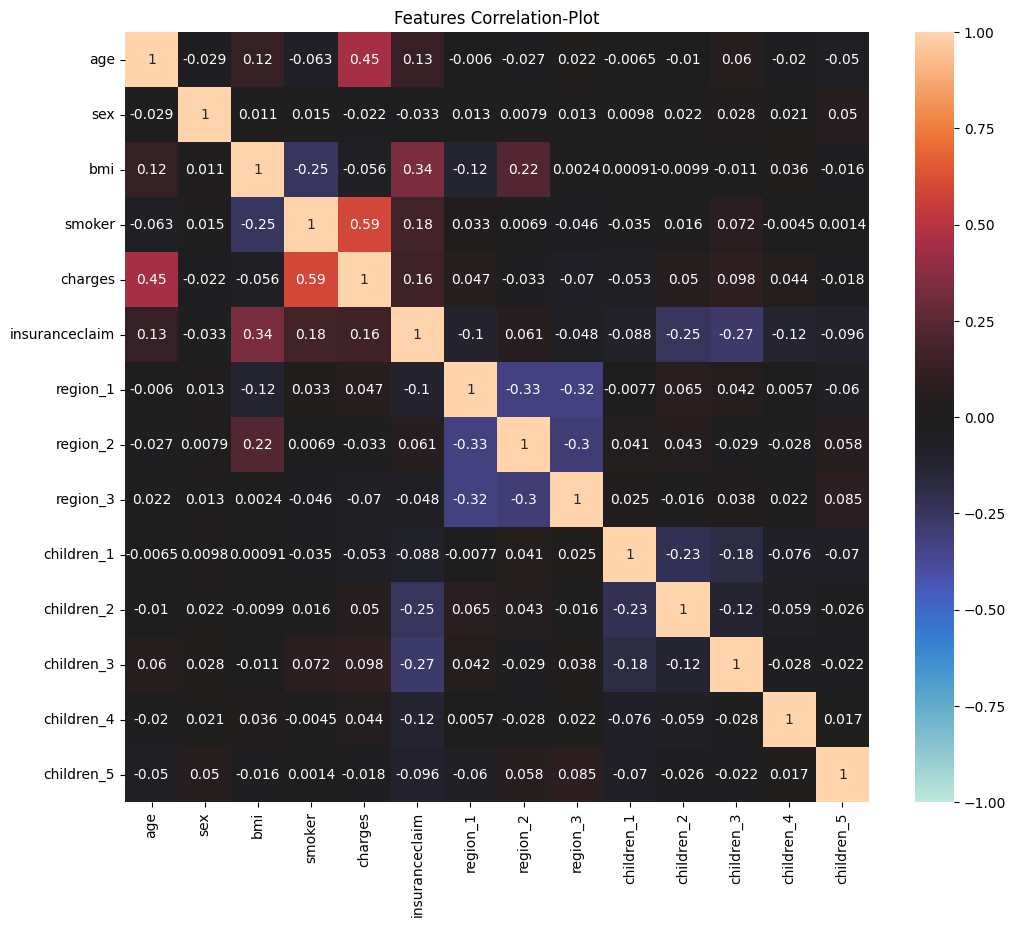

In [54]:
#Checking the correlation

features = df.columns
plt.figure(figsize=[12,10])
plt.title('Features Correlation-Plot')
sns.heatmap(df[features].corr(), vmin=-1, vmax=1, center=0, annot=True) #, 
plt.show()

Inference:  Correlation plt between the variables convey lot of information about the realationship betweem them. There seems to be strong multicollinearity in the dataset.

Let us check with different techniques if we can improve the model's performance by performing Feature Selection/Extraction steps to take care of these multi-collinearity...

Strategy:  We can fix these multicollinearity with two techniques:

Manual Method - Variance Inflation Factor (VIF)
Automatic Method - Recursive Feature Elimination (RFE)
Decomposition Method - Principle Component Analysis (PCA)

### 5a. Manual Method - VIF

100%|██████████| 12/12 [00:03<00:00,  3.63it/s]


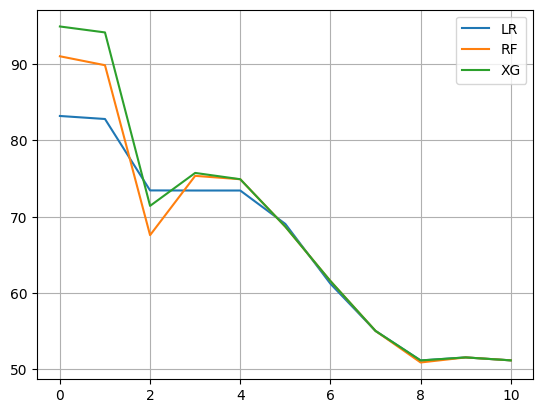

In [63]:
# Calculate the VIFs to remove multicollinearity

DROP=[]; scores1=[]; scores2=[]; scores3=[]
#scores.append(f1_score(Test_Y,LogisticRegression().fit(Train_X_std, Train_Y).predict(Test_X_std)))
scores1.append(f1_score(Test_Y,LogisticRegression().fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
scores2.append(f1_score(Test_Y,RandomForestClassifier().fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
scores3.append(f1_score(Test_Y,XGBClassifier(eval_metric='logloss').fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
        
for i in tqdm(range(len(X.columns.values)-1)):
    vif = pd.DataFrame()
    Xs = X.drop(DROP,axis=1)

    # ensure all columns are numeric (coerce non-numeric to NaN then fill)
    Xs = Xs.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)

    # compute VIFs safely — catch errors and mark as inf
    vif['Features'] = Xs.columns
    vif_vals = []
    for j in range(Xs.shape[1]):
        try:
            v = variance_inflation_factor(Xs.values, j)
            # protect against non-finite results
            if not np.isfinite(v):
                v = np.inf
        except Exception:
            v = np.inf
        vif_vals.append(v)

    vif['VIF'] = [round(x, 2) if np.isfinite(x) else np.inf for x in vif_vals]
    vif = vif.sort_values(by = "VIF", ascending = False)
    vif.reset_index(drop=True, inplace=True)
    DROP.append(vif.Features[0])
    if vif.VIF[0]>1:
        scores1.append(f1_score(Test_Y,LogisticRegression().fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
        scores2.append(f1_score(Test_Y,RandomForestClassifier().fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
        scores3.append(f1_score(Test_Y,XGBClassifier(eval_metric='logloss').fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
    #print(scores)
    
plt.plot(scores1, label='LR')
plt.plot(scores2, label='RF')
plt.plot(scores3, label='XG')
#plt.ylim([0.7,0.85])
plt.legend()
plt.grid()
plt.show()

### 5b. Automatic Method - RFE

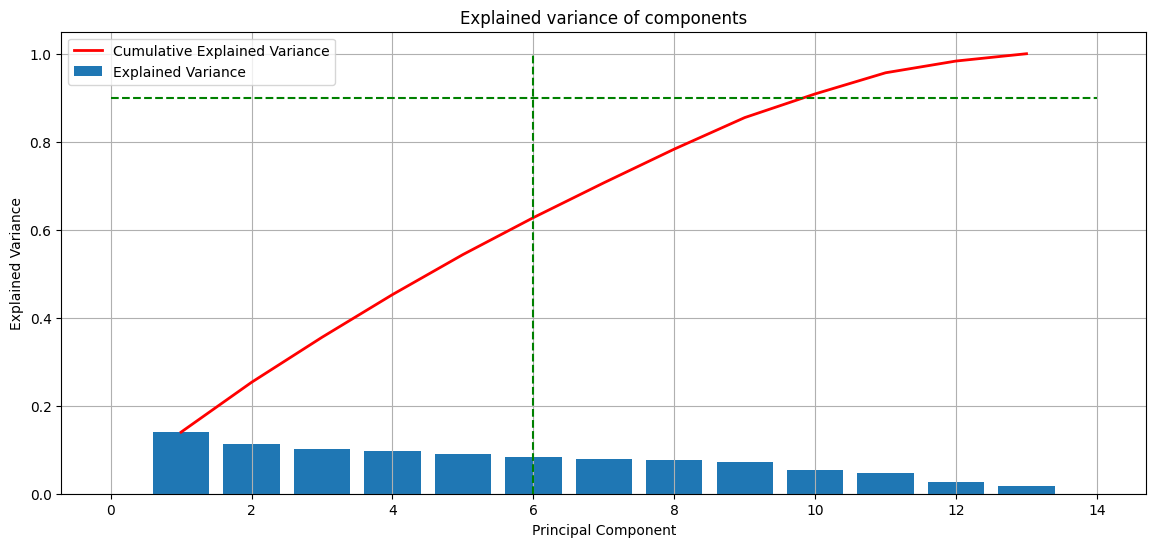

In [64]:
from sklearn.decomposition import PCA

pca = PCA().fit(Train_X_std)

fig, ax = plt.subplots(figsize=(14,6))
x_values = range(1, pca.n_components_+1)
ax.bar(x_values, pca.explained_variance_ratio_, lw=2, label='Explained Variance')
ax.plot(x_values, np.cumsum(pca.explained_variance_ratio_), lw=2, label='Cumulative Explained Variance', color='red')
plt.plot([0,pca.n_components_+1],[0.90,0.90],'g--')
plt.plot([6,6],[0,1], 'g--')
ax.set_title('Explained variance of components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance')
plt.grid()
plt.legend()
plt.show()

Inference: We shall avoid performing dimensionality reduction for the current problem.

100%|██████████| 13/13 [00:04<00:00,  2.82it/s]


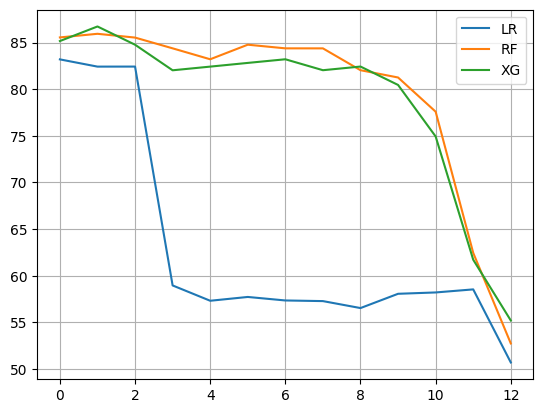

In [67]:
from sklearn.decomposition import PCA

scores1=[]; scores2=[]; scores3=[]
for i in tqdm(range(len(X.columns.values))):
    n_comp = max(1, Train_X_std.shape[1]-i)
    pca = PCA(n_components=n_comp)
    Train_X_std_pca = pca.fit_transform(Train_X_std)
    Train_X_std_pca = pd.DataFrame(Train_X_std_pca)

    Test_X_std_pca = pca.transform(Test_X_std)
    Test_X_std_pca = pd.DataFrame(Test_X_std_pca)

    scores1.append(f1_score(Test_Y, LogisticRegression().fit(Train_X_std_pca, Train_Y).predict(Test_X_std_pca), average='weighted')*100)
    scores2.append(f1_score(Test_Y, RandomForestClassifier().fit(Train_X_std_pca, Train_Y).predict(Test_X_std_pca), average='weighted')*100)
    scores3.append(f1_score(Test_Y, XGBClassifier(eval_metric='logloss').fit(Train_X_std_pca, Train_Y).predict(Test_X_std_pca), average='weighted')*100)

plt.plot(scores1, label='LR')
plt.plot(scores2, label='RF')
plt.plot(scores3, label='XG')
#plt.ylim([0.80,0.84])
plt.legend()
plt.grid()
plt.show()


Inference: In VIF, RFE & PCA Techniques, we did notice any better scores upon dropping some multicollinear features. But in order to avoid the curse of dimensionality, we can capture top 90% of the data Variance explained by top n PCA components.

In [70]:
#### Finalising the shortlisted features

# Use LogisticRegression() instance as estimator for RFE
rfe = RFE(LogisticRegression(), n_features_to_select=len(Train_X_std.columns))   
rfe = rfe.fit(Train_X_std, Train_Y)

# Evaluate models on the selected features
sel_cols = Train_X_std.columns[rfe.support_]
print(f1_score(Test_Y, LogisticRegression().fit(Train_X_std[sel_cols], Train_Y).predict(Test_X_std[sel_cols]), average='weighted')*100)
print(f1_score(Test_Y, RandomForestClassifier().fit(Train_X_std[sel_cols], Train_Y).predict(Test_X_std[sel_cols]), average='weighted')*100)
print(f1_score(Test_Y, XGBClassifier(eval_metric='logloss').fit(Train_X_std[sel_cols], Train_Y).predict(Test_X_std[sel_cols]), average='weighted')*100)
    
# Optionally keep only selected columns
# Train_X_std = Train_X_std[Train_X_std.columns[rfe.support_]]
# Test_X_std = Test_X_std[Test_X_std.columns[rfe.support_]]

print(Train_X_std.shape)
print(Test_X_std.shape)

NameError: name 'RFE' is not defined